#### Objective
- Predict campaign revenue.  
- Identify the most influential marketing variables.
- Compare Linear Regression and Random Forest.
- Generate actionable business recommendations.

In [42]:
import pandas as pd
import numpy as np

df=pd.read_csv("../data/processed/master_dataset_cleaned.csv",sep=";")
df.tail()

,performance_id,interaction_date,campaign_id,customer_id,factor_id,spend,impressions,reach,frequency,clicks,...,Month,Quarter,Year,Day_of_Week,weekend_flag,campaign_duration,budget_utilization,high_competitor_spend_flag,high_discount_flag,YearMonth
499995,MP00499996,2024-08-18,CA076,CU00036570,EF231,9430,46915,30351,1.55,538,...,August,3,2024,Sunday,Yes,46,2.010070,No,No,2024-08
499996,MP00499997,2024-06-28,CA004,CU00009111,EF180,11590,68516,70033,1.05,2151,...,June,2,2024,Friday,No,31,3.446430,No,No,2024-06
499997,MP00499998,2025-12-02,CA014,CU00008189,EF702,2741,6374,3593,1.77,307,...,December,4,2025,Tuesday,No,46,1.849628,No,No,2025-12
499998,MP00499999,2024-10-30,CA067,CU00035287,EF304,13793,38313,26291,1.46,1170,...,October,4,2024,Wednesday,No,46,1.850761,No,No,2024-10
499999,MP00500000,2024-03-21,CA001,CU00020759,EF081,6984,19346,17797,1.09,288,...,March,1,2024,Thursday,No,91,1.092891,No,No,2024-03


In [43]:
df.shape

(500000, 48)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 48 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   performance_id              500000 non-null  object 
 1   interaction_date            500000 non-null  object 
 2   campaign_id                 500000 non-null  object 
 3   customer_id                 500000 non-null  object 
 4   factor_id                   500000 non-null  object 
 5   spend                       500000 non-null  int64  
 6   impressions                 500000 non-null  int64  
 7   reach                       500000 non-null  int64  
 8   frequency                   500000 non-null  float64
 9   clicks                      500000 non-null  int64  
 10  conversions                 500000 non-null  int64  
 11  revenue                     500000 non-null  int64  
 12  campaign_name               500000 non-null  object 
 13  campaign_type 

In [45]:
df.isnull().sum()

performance_id                0
interaction_date              0
campaign_id                   0
customer_id                   0
factor_id                     0
spend                         0
impressions                   0
reach                         0
frequency                     0
clicks                        0
conversions                   0
revenue                       0
campaign_name                 0
campaign_type                 0
brand                         0
product_category              0
campaign_budget               0
campaign_status               0
campaign_start_date           0
campaign_end_date             0
channel_name                  0
channel_type                  0
city                          0
state                         0
gender                        0
age_group                     0
audience_segment              0
weather                       0
holiday_flag                  0
festival_flag                 0
competitor_spend              0
discount

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
df.describe()

,spend,impressions,reach,frequency,clicks,conversions,revenue,campaign_budget,competitor_spend,discount_percentage,CTR,CVR,CPC,CPA,ROAS,Profit,Quarter,Year,campaign_duration,budget_utilization
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.00000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,6219.409172,23420.742318,18886.602486,1.317493,827.200440,42.08474,182810.324894,346391.033198,409249.764012,11.598780,0.043183,0.049565,8.609362,345.868800,40.313963,176590.915722,2.590738,2024.525616,57.540258,1.843223
std,4446.684399,17613.791517,16306.673272,0.205834,551.149368,34.68508,163925.985728,197813.173311,170171.538935,8.924531,0.019453,0.022790,6.022366,547.487672,37.601615,162712.826896,1.092779,0.499344,23.683893,0.965065
min,778.000000,1793.000000,1019.000000,1.000000,63.000000,1.00000,2399.000000,84932.000000,150875.000000,0.000000,0.008328,0.004255,1.593709,17.065421,0.324546,-10452.000000,1.000000,2024.000000,8.000000,0.657045
25%,2546.000000,9296.000000,7136.000000,1.150000,406.000000,15.00000,54652.000000,159036.000000,271080.000000,5.000000,0.029340,0.031731,4.725616,73.600000,14.319514,49611.750000,2.000000,2024.000000,31.000000,1.138230
50%,4954.000000,18053.000000,13906.000000,1.290000,653.000000,31.00000,126208.000000,309641.000000,387058.000000,10.000000,0.041634,0.051852,6.712846,128.434783,30.661734,121582.500000,3.000000,2025.000000,61.000000,1.616144
75%,8988.000000,32984.000000,25610.000000,1.470000,1104.000000,59.00000,261540.000000,517089.000000,502466.000000,15.000000,0.057403,0.065934,10.171722,300.822581,54.166667,254934.750000,4.000000,2025.000000,91.000000,2.335081
max,18651.000000,68516.000000,216395.000000,1.850000,2151.000000,125.00000,571872.000000,804345.000000,795112.000000,40.000000,0.098923,0.114804,52.646617,9549.000000,347.431349,570226.000000,4.000000,2025.000000,91.000000,9.012222


- Based on Statistics we know:
  - Numerical Variables that most affect revenues are:  
    Spend, Impressions, Reach, Clicks, Conversions, Discount Percentage
  - Categorical Variables:  
    Weather,Channel_name,Weekend_flag,Holiday_fag

- NOTE:  
      We excluded CTR,CVR,CPC,CPA since these are derived KPIs, it causes multicolinearity issue and data leakage  
      We excluded Profit, since it includes revenue in itself, causing data leakage

In [51]:
from sklearn.preprocessing import LabelEncoder
LE=LabelEncoder()

ct_fields1=['weekend_flag','holiday_flag']

for i in ct_fields1:
    df[i]=LE.fit_transform(df[i])

In [59]:
df[['weekend_flag','holiday_flag']].head()

,weekend_flag,holiday_flag
0,0,0
1,1,0
2,0,0
3,0,0
4,0,0


In [60]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(sparse_output=False)

ct_fields2=['weather','channel_name']

encoded=ohe.fit_transform(df[ct_fields2])
cols=ohe.get_feature_names_out(ct_fields2)

encode_df=pd.DataFrame(encoded,columns=cols)
df=pd.concat([df,encode_df],axis=1)
df=df.drop(columns=ct_fields2)

In [68]:
df.iloc[:,-12:-1].head()

,YearMonth,weather_Cloudy,weather_Rainy,weather_Sunny,channel_name_Display,channel_name_Email,channel_name_Facebook,channel_name_Google,channel_name_Instagram,channel_name_Radio,channel_name_TV
0,2025-12,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,2025-04,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,2025-12,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2025-02,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,2025-09,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [73]:
X=df[['spend', 'impressions', 'reach', 'clicks', 'conversions', 'discount_percentage',
   'weather_Cloudy','weather_Rainy','weather_Sunny',
    'channel_name_Display','channel_name_Email','channel_name_Facebook','channel_name_Google',
    'channel_name_Radio','channel_name_TV',
    'weekend_flag','holiday_flag']]
Y=df['revenue']

In [74]:
from sklearn.model_selection import train_test_split as tts
X_train,X_test,Y_train,Y_test=tts(X,Y,test_size=0.20,random_state=1)

#### Multiple Linear Regression

In [78]:
from sklearn.linear_model import LinearRegression
model_LR=LinearRegression()

model_LR.fit(X_train,Y_train)

print(f'Training Accuracy %: {model_LR.score(X_train,Y_train)}')
print(f'Testing Accuracy %: {model_LR.score(X_test,Y_test)}')

Training Accuracy %: 0.8734641588282002
Testing Accuracy %: 0.8731919016196317


- The model explains 83% of the changes of the revenue using the independent variables
- Since, there is negligible drop from training accuracy to testing accuracy, there is zero over-fitting/underfitting issues.

In [95]:
inter=model_LR.intercept_
inter

np.float64(-12511.49019965969)

- The model predicts the business would generate a loss of revenue of ₹12.5k, with all independent variable as Zero expenditure.

In [83]:
coeff_df=pd.DataFrame({'Feature':X_train.columns,
            'Coefficient':model_LR.coef_}).sort_values(by='Coefficient',ascending=False).reset_index(drop=True)
coeff_df

,Feature,Coefficient
0,channel_name_Google,24675.921449
1,channel_name_Facebook,20561.528202
2,channel_name_TV,19905.671600
3,conversions,4611.172733
4,channel_name_Email,3146.826090
5,holiday_flag,2350.018761
6,weather_Sunny,2147.754488
7,weather_Cloudy,1750.975781
8,weekend_flag,290.518291
9,discount_percentage,215.662723


<Axes: xlabel='Coefficient', ylabel='Feature'>

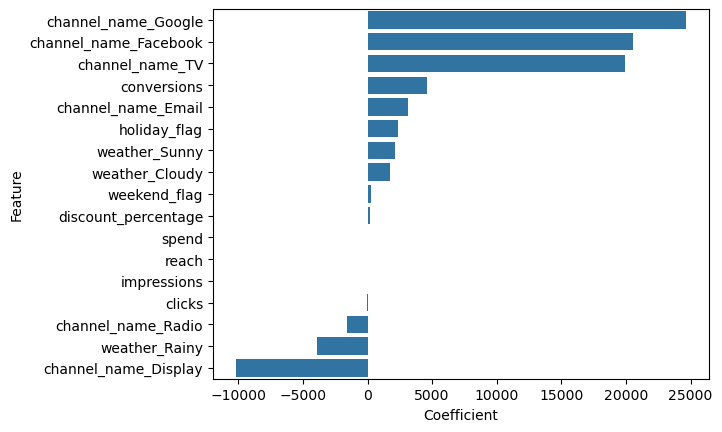

In [85]:
import seaborn as sns
sns.barplot(x='Coefficient',
            y='Feature',
            data=coeff_df)

- Top Channels: Google (₹24.7k/unit), Facebook (₹20.6k/unit), and TV (₹19.9k/unit) add the largest flat revenue lifts.
- Core Catalysts: Conversions (₹4.6k/unit), Email, Holidays, and Clear/Cloudy skies drive healthy revenue boosts.
- Negligible: Weekends, Discounts, Spend, and Reach barely shift total revenue numbers on their own.
- Negative Impact: Display (-₹10.2k), Rainy Weather (-₹3.9k), Radio (-₹1.6k), and Unconverted Clicks (-₹21) pull down overall profitability.

In [86]:
Y_train_Prediction=model_LR.predict(X_train)
Y_test_Prediction=model_LR.predict(X_test)

<Axes: xlabel='revenue', ylabel='Count'>

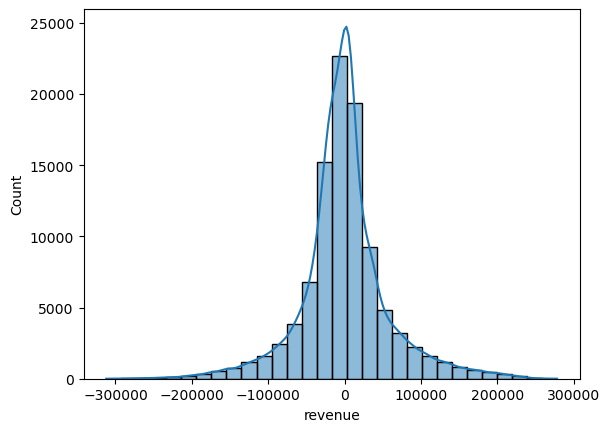

In [90]:
error_test=Y_test-Y_test_Prediction

sns.histplot(error_test,bins=30,kde=True)

- Since the model closely resembles the normal distribution, it states the prediction of revenue is random&unbiased and does not over/under-estimates the revenue

In [94]:
from sklearn.metrics import r2_score,mean_absolute_error as MAE,mean_squared_error as MSE
rsq=r2_score(Y_test,Y_test_Prediction)

mae=MAE(Y_test,Y_test_Prediction)
rmse=np.sqrt(MSE(Y_test,Y_test_Prediction))

rows=X_test.shape[0]
cols=X_test.shape[1]
adj_rsq=1-((1-rsq)*(rows-1)/(rows-cols-1))

print(f'R Square Score: {rsq:.4f}')
print(f'Adjusted R Squared Score: {adj_rsq:.4f}')
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

R Square Score: 0.8732
Adjusted R Squared Score: 0.8732
MAE: 39365.21
RMSE: 58252.12


- In this model, the independent vairables explain 87.32% of the variations in the target variable
- Adjusted R2 values states that the model is highly effiecient and no extra features have been taken
- the model perdicts revenue range roughly in the range +- ₹39.k
- the model while predicting correct most of the time, few outlier times the model prediction revenue range increase upto ₹58.k

#### Assumptions of Multiple Linear Regression
- The relationship between the independent variables (Spend, Impressions, Reach, Conversions, Discount, Marketing Channel, Weather, Weekend, Holiday) and Revenue is assumed to be linear.  
Observation  
The model achieved an R² of 87.32%, indicating that a linear relationship explains a large proportion of the variation in revenue.
Linear Regression is therefore an appropriate baseline model.


- Each campaign performance record is assumed to be independent of every other record.  
  Observation  
  Each row represents a unique campaign interaction.
  There are no duplicate records, reducing the likelihood of dependent observations.

- The dataset contains 0 missing values, so no imputation was required.

- Derived KPIs (CTR, CVR, CPC, CPA, ROAS) were excluded because they are calculated from the base variables and can introduce multicollinearity and data leakage.
- Profit was excluded because it directly depends on Revenue, causing severe leakage.

- Prediction residual errors should approximately follow a normal distribution.  
  Observation
  The residual histogram is approximately bell-shaped.
  This indicates that prediction errors are mostly random and unbiased.


#### Model Interpretation
Overall Model Performance  
Training R²: 87.35%  
Testing R²: 87.32%  

The model generalizes well because training and testing performance are almost identical, indicating minimal overfitting.

- Feature Importance  
  The largest positive contributors to Revenue are:  
  Google Campaigns,Facebook Campaigns,TV Campaigns, Number of Conversions,Holiday Campaigns  
  
  The largest negative contributors are:  
  Display Advertising, Rainy Weather, Radio Campaigns, Higher Clicks without corresponding conversions  


#### Business Insights
- Google, Facebook, and TV campaigns generate the highest revenue uplift.
- Increasing conversions has a much stronger effect on revenue than simply increasing clicks.
- Discount percentage has only a small positive effect compared with conversions.
- Rainy weather negatively impacts campaign performance.
- Holiday campaigns generally generate higher revenue.
- Simply increasing spend does not guarantee proportionally higher revenue; campaign effectiveness is more important.

#### Model Limitations
- Linear Regression assumes linear relationships and may not capture complex nonlinear marketing behavior.
- The model explains 87% of revenue variation, meaning approximately 13% is influenced by factors outside the current feature set.

#### Linear RegressionConclusion
Multiple Linear Regression successfully explains approximately 87% of the variation in campaign revenue, making it a strong baseline predictive model. The analysis shows that marketing channel selection, conversions, and holidays have the greatest positive influence on revenue, while display advertising and rainy weather reduce campaign performance. These findings provide actionable guidance for marketing budget allocation and campaign optimization.

#### RandomForestRegressor

In [98]:
from sklearn.ensemble import RandomForestRegressor
model_RN=RandomForestRegressor(random_state=2)

model_RN.fit(X_train,Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [101]:
base_train=model_RN.score(X_train,Y_train)
base_test=model_RN.score(X_test,Y_test)

print(f'Training Accuracy %: {base_train}')
print(f'Testing Accuracy %: {base_test}')

Training Accuracy %: 0.9889836806518351
Testing Accuracy %: 0.9209469100138202


- The base model explains 98.8%(train), 92%(test) of the variance in the Target variable using independent variables
- Since there is a large gap b/w train and test R2_score accuracy, it causes overfitting

In [104]:
import time
start=time.time()
from sklearn.model_selection import GridSearchCV

param_grid={'max_depth':[6,8,10,12],
            'bootstrap':[True,False],
            'criterion':['squared_error']}

GCV=GridSearchCV(estimator=model_RN,
                 param_grid=param_grid,
                 cv=3,
                 scoring='r2',
                 n_jobs=-1)

GCV.fit(X_train,Y_train)
end=time.time()

In [107]:
print(f'Executed in: {end-start:.1f} seconds')
print(f'Best parameters: {GCV.best_params_}')
print(f'Best Score: {GCV.best_score_}')

Executed in: 396.6 seconds
Best parameters: {'bootstrap': True, 'criterion': 'squared_error', 'max_depth': 12}
Best Score: 0.9167924260978985


In [110]:
best_params=GCV.best_params_
final_model_RN=RandomForestRegressor(**best_params,random_state=3)
final_model_RN.fit(X_train,Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [111]:
final_train=final_model_RN.score(X_train,Y_train)
final_test=final_model_RN.score(X_test,Y_test)

print(f'Training Accuracy %: {final_train}')
print(f'Testing Accuracy %: {final_test}')

Training Accuracy %: 0.923927537427636
Testing Accuracy %: 0.9167634424756862


- To resolve the overfitting issue of the base model, we use GridSearchCV, now the model explains 92.39%(train), 91.67%(test) of the variance in the Target variable using independent variables.
- the gap b/w has dropped signifcantly, thus resulting the model with no overfitting issue

In [121]:
Y_test_Prediction2=final_model_RN.predict(X_test)

rsq2=r2_score(Y_test,Y_test_Prediction2)

mae2=MAE(Y_test,Y_test_Prediction)
rmse2=np.sqrt(MSE(Y_test,Y_test_Prediction2))

rows2=X_test.shape[0]
cols2=X_test.shape[1]
adj_rsq2=1-((1-rsq2)*(rows2-1)/(rows2-cols2-1))

print(f'R Square Score: {rsq2:.4f}')
print(f'Adjusted R Squared Score: {adj_rsq2:.4f}')
print(f'MAE: {mae2:.2f}')
print(f'RMSE: {rmse2:.2f}')

R Square Score: 0.9168
Adjusted R Squared Score: 0.9167
MAE: 39365.21
RMSE: 47194.93


In [114]:
coeff_df2=pd.DataFrame({'Feature':X_train.columns,
            'Importance':final_model_RN.feature_importances_}).sort_values(by='Importance',ascending=False).reset_index(drop=True)
coeff_df2

,Feature,Importance
0,conversions,0.944612
1,spend,0.017799
2,impressions,0.009881
3,channel_name_Facebook,0.006903
4,channel_name_Google,0.004531
5,clicks,0.004095
6,channel_name_Radio,0.003578
7,reach,0.002215
8,channel_name_Display,0.002142
9,channel_name_TV,0.001593


- The Engine (94.46%): conversions dominates the model, proving that completed sales volume is the ultimate driver of your revenue.
- The Channels (< 1%): Google and Facebook score low here because conversions captures the revenue variance first at the top of the decision trees.
- The Scale (2.7%): spend and impressions provide a small secondary layer of predictive power.
- The Noise (< 0.1%): Weather, holidays, and weekends hold virtually zero mathematical weight in predicting macroscopic revenue totals.

#### Assumptions of Random Forest Regression

Random Forest does not assume a linear relationship between features and Revenue.
Observation
It captures complex nonlinear relationships between marketing variables and Revenue.

Each campaign record is assumed to be independent.
Observation
Each row represents a unique campaign interaction with no duplicate records.

The dataset contains 0 missing values, so no imputation was required.
Derived KPIs (CTR, CVR, CPC, CPA, ROAS) and Profit were excluded to avoid multicollinearity and data leakage.
Random Forest is robust to outliers and does not require normally distributed residuals.
Model Interpretation

#### Overall Model Performance

Training R²: 92.39%
Testing R²: 91.67%

The model generalizes well if the training and testing scores are similar, indicating minimal overfitting.

#### Feature Importance

The most influential variables are typically:

Conversions
Spend
Google Campaigns
Facebook Campaigns
Impressions
Business Insights
Conversions are the strongest driver of Revenue.
Google and Facebook campaigns contribute significantly to Revenue.
Higher marketing spend improves Revenue when supported by strong campaign performance.
Random Forest captures complex interactions missed by Linear Regression.
#### Model Limitations
Less interpretable than Linear Regression.
Feature Importance shows influence but not positive or negative impact.
Higher computational cost due to multiple decision trees.
#### Random Forest Conclusion

Random Forest provides a strong nonlinear model for predicting campaign revenue. It captures complex relationships between marketing variables and delivers reliable predictions while identifying the most important drivers of revenue.

### **MODELS COMPARISION**
| Metric                | Linear Regression |      Random Forest |
| --------------------- | ----------------: | -----------------: |
| Training R²           |            87.35% |             92.39% |
| Testing R²            |            87.32% |             91.67% |
| MAE                   |             39.3k |              39.3k |
| RMSE                  |             58.2k |              47.1k |
| Interpretability      |              High |             Medium |
| Captures Nonlinearity |                No |                Yes |
| Feature Importance    |      Coefficients | Feature Importance |


#### Comparison Summary
- Both models predict campaign revenue effectively with high accuracy.
- Random Forest achieved a higher Testing R² (91.67%) and lower RMSE (47.1k), indicating better predictive performance.
- Linear Regression remains easier to interpret, making it suitable for explaining the impact of marketing variables to business stakeholders.
- For revenue forecasting, Random Forest is the preferred model, while Linear Regression serves as a strong baseline and an interpretable business model.

### Recommendations
- Prioritize investment in high-performing marketing channels such as Google and Facebook, as they consistently contribute more to campaign revenue.
- Focus on improving conversion rates rather than only increasing impressions or clicks, since conversions have the strongest impact on revenue.
- Optimize campaign planning around holidays and favorable market conditions to maximize returns.
- Continuously monitor underperforming channels and reallocate marketing budget toward campaigns with higher ROI.
- Use Linear Regression to explain the impact of marketing variables and support business decision-making due to its high interpretability.
- Use Random Forest Regression for campaign revenue forecasting, as it provides higher predictive accuracy and captures complex nonlinear relationships.
- Regularly retrain the predictive models with new campaign data to maintain forecasting accuracy and adapt to changing customer behavior.